# Eksplorativna analiza podataka o automobilima



Cilj ove radne sveske je da istraži skup `cars.csv`, proveri kvalitet podataka i opiše ciljnu promenljivu `priceUSD`. Analiza obuhvata dimenzije skupa, tipove podataka, nedostajuće vrednosti, numeričke i kategorijske kolone i ekstremne vrednosti.

In [10]:
from pathlib import Path



import matplotlib.pyplot as plt

import pandas as pd

import seaborn as sns

from IPython.display import display



sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)



data_path = Path("../data/cars.csv")

if not data_path.exists():

    data_path = Path("data/cars.csv")



cars = pd.read_csv(data_path)

cars.head()

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,B


## 1. Broj redova i kolona



Dimenzije skupa pokazuju koliko zapisa (redova) i atributa (kolona) je dostupno za dalju analizu. Prikazuju se i broj dupliranih redova i mali uzorak podataka kao početna kontrola učitavanja.

In [11]:
rows, columns = cars.shape

print(f"Broj redova: {rows:,}")

print(f"Broj kolona: {columns}")

print(f"Broj dupliranih redova: {cars.duplicated().sum():,}")

Broj redova: 56,244
Broj kolona: 12
Broj dupliranih redova: 87


## 2. Tipovi podataka



Pregled tipova otkriva koje kolone Pandas tretira kao numeričke, a koje kao tekstualne. To je važno za izbor statističkih analiza i kasnije pretprocesiranje.

In [12]:
dtype_summary = pd.DataFrame({

    "tip_podatka": cars.dtypes.astype(str),

    "broj_jedinstvenih": cars.nunique(dropna=True),

})

dtype_summary

,tip_podatka,broj_jedinstvenih
make,str,96
model,str,1034
priceUSD,int64,2970
year,int64,78
condition,str,3
mileage(kilometers),float64,8400
fuel_type,str,3
volume(cm3),float64,458
color,str,13
transmission,str,2


## 3. Nedostajuće vrednosti



Nedostajuće vrednosti se prikazuju kao broj i procenat po koloni. Grafikon izdvaja samo kolone koje zahtevaju obradu, kako kolone bez nedostajućih vrednosti ne bi zaklanjale problem.

,broj_nedostajucih,procenat_nedostajucih
segment,5291,9.41%
drive_unit,1905,3.39%
volume(cm3),47,0.08%
make,0,0.00%
year,0,0.00%
priceUSD,0,0.00%
model,0,0.00%
condition,0,0.00%
fuel_type,0,0.00%
mileage(kilometers),0,0.00%


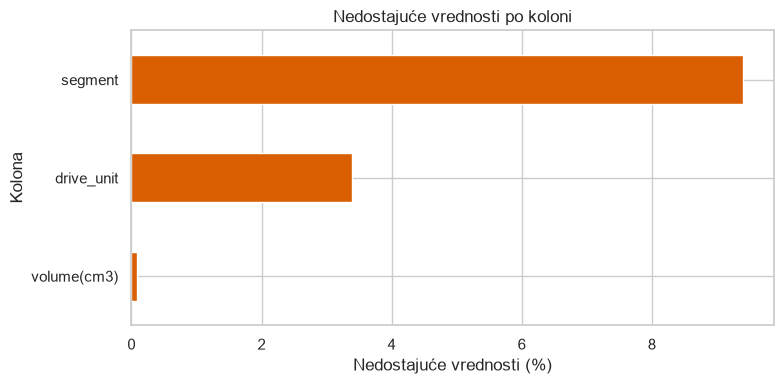

In [13]:
missing_summary = (

    pd.DataFrame({

        "broj_nedostajucih": cars.isna().sum(),

        "procenat_nedostajucih": cars.isna().mean().mul(100),

    })

    .sort_values("broj_nedostajucih", ascending=False)

)

display(missing_summary.style.format({"procenat_nedostajucih": "{:.2f}%"}))



missing_to_plot = missing_summary.query("broj_nedostajucih > 0").sort_values("procenat_nedostajucih")

ax = missing_to_plot["procenat_nedostajucih"].plot(

    kind="barh", figsize=(8, 4), color="#d95f02", title="Nedostajuće vrednosti po koloni"

)

ax.set_xlabel("Nedostajuće vrednosti (%)")

ax.set_ylabel("Kolona")

plt.tight_layout()

plt.show()

## 4. Ciljna promenljiva `priceUSD`



`priceUSD` je cilj koji će regresioni model predviđati. Deskriptivna statistika, histogram i boxplot prikazuju tipičnu cenu, raspon i asimetriju raspodele. Histogram je ograničen na 99. percentil radi čitljivosti, dok boxplot prikazuje ceo raspon podataka.

,count,mean,std,min,25%,50%,75%,max
priceUSD,56244.0,7415.45644,8316.959261,48.0,2350.0,5350.0,9807.5,235235.0


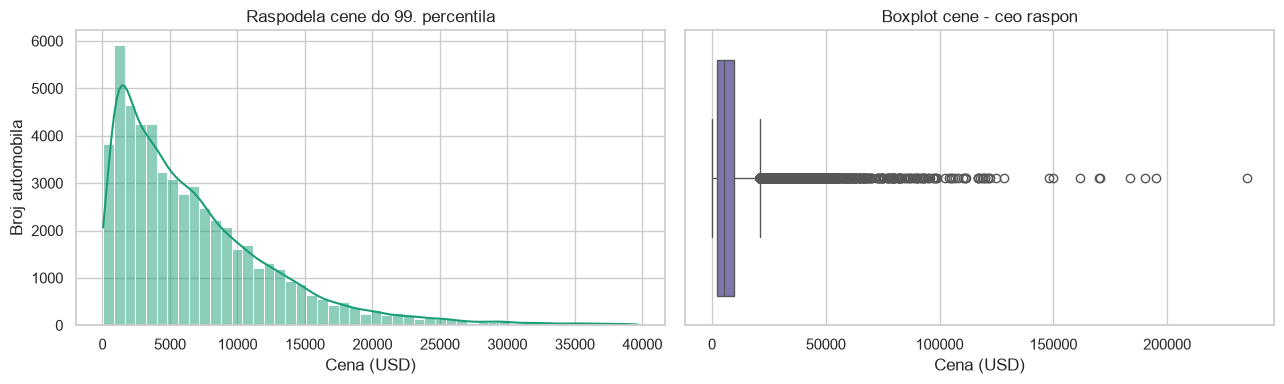

Medijana cene: 5,350 USD
99. percentil: 39,728 USD
Koeficijent asimetrije: 5.14


In [14]:
price = cars["priceUSD"]

display(price.describe().to_frame(name="priceUSD").T)



fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(price[price <= price.quantile(0.99)], bins=50, kde=True, ax=axes[0], color="#1b9e77")

axes[0].set_title("Raspodela cene do 99. percentila")

axes[0].set_xlabel("Cena (USD)")

axes[0].set_ylabel("Broj automobila")



sns.boxplot(x=price, ax=axes[1], color="#7570b3")

axes[1].set_title("Boxplot cene - ceo raspon")

axes[1].set_xlabel("Cena (USD)")

plt.tight_layout()

plt.show()



print(f"Medijana cene: {price.median():,.0f} USD")

print(f"99. percentil: {price.quantile(0.99):,.0f} USD")

print(f"Koeficijent asimetrije: {price.skew():.2f}")

## 5. Numeričke kolone



Numeričke kolone se automatski izdvajaju prema tipu podatka. Tabela opisuje centralne vrednosti i raspon, dok korelaciona mapa prikazuje linearne veze između numeričkih atributa. Korelacija ne predstavlja nužno uzročnost.

Numeričke kolone: ['priceUSD', 'year', 'mileage(kilometers)', 'volume(cm3)']


,count,mean,std,min,25%,50%,75%,max
priceUSD,56244.0,7415.456440,8316.959261,48.0,2350.0,5350.0,9807.5,235235.0
year,56244.0,2003.454840,8.144247,1910.0,1998.0,2004.0,2010.0,2019.0
mileage(kilometers),56244.0,244395.631020,321030.668382,0.0,137000.0,228500.0,310000.0,9999999.0
volume(cm3),56197.0,2104.860615,959.201633,500.0,1600.0,1996.0,2300.0,20000.0


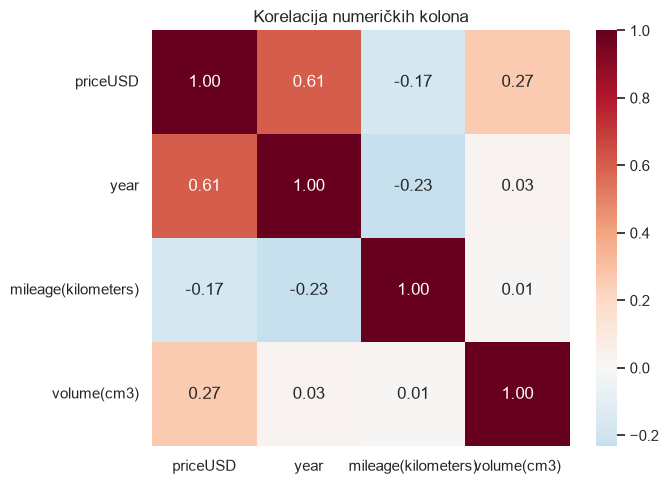

In [15]:
numeric_columns = cars.select_dtypes(include="number").columns.tolist()

print("Numeričke kolone:", numeric_columns)

display(cars[numeric_columns].describe().T)



plt.figure(figsize=(7, 5))

sns.heatmap(cars[numeric_columns].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)

plt.title("Korelacija numeričkih kolona")

plt.tight_layout()

plt.show()

## 6. Kategorijske kolone



Za kategorijske kolone prikazuju se broj jedinstvenih vrednosti, najčešća kategorija i njen udeo. Posebni grafikoni prikazuju raspodele kategorija sa malim brojem mogućih vrednosti, dok se `make` i `model` ne crtaju u celini zbog velike kardinalnosti.

Kategorijske kolone: ['make', 'model', 'condition', 'fuel_type', 'color', 'transmission', 'drive_unit', 'segment']


,broj_popunjenih,broj_kategorija,najcesca,frekvencija,udeo_najcesce_%
make,56244,96,volkswagen,6861,12.20%
model,56244,1034,passat,2086,3.71%
condition,56244,3,with mileage,55278,98.28%
fuel_type,56244,3,petrol,36405,64.73%
color,56244,13,black,12385,22.02%
transmission,56244,2,mechanics,36056,64.11%
drive_unit,54339,4,front-wheel drive,38016,69.96%
segment,50953,9,D,12605,24.74%


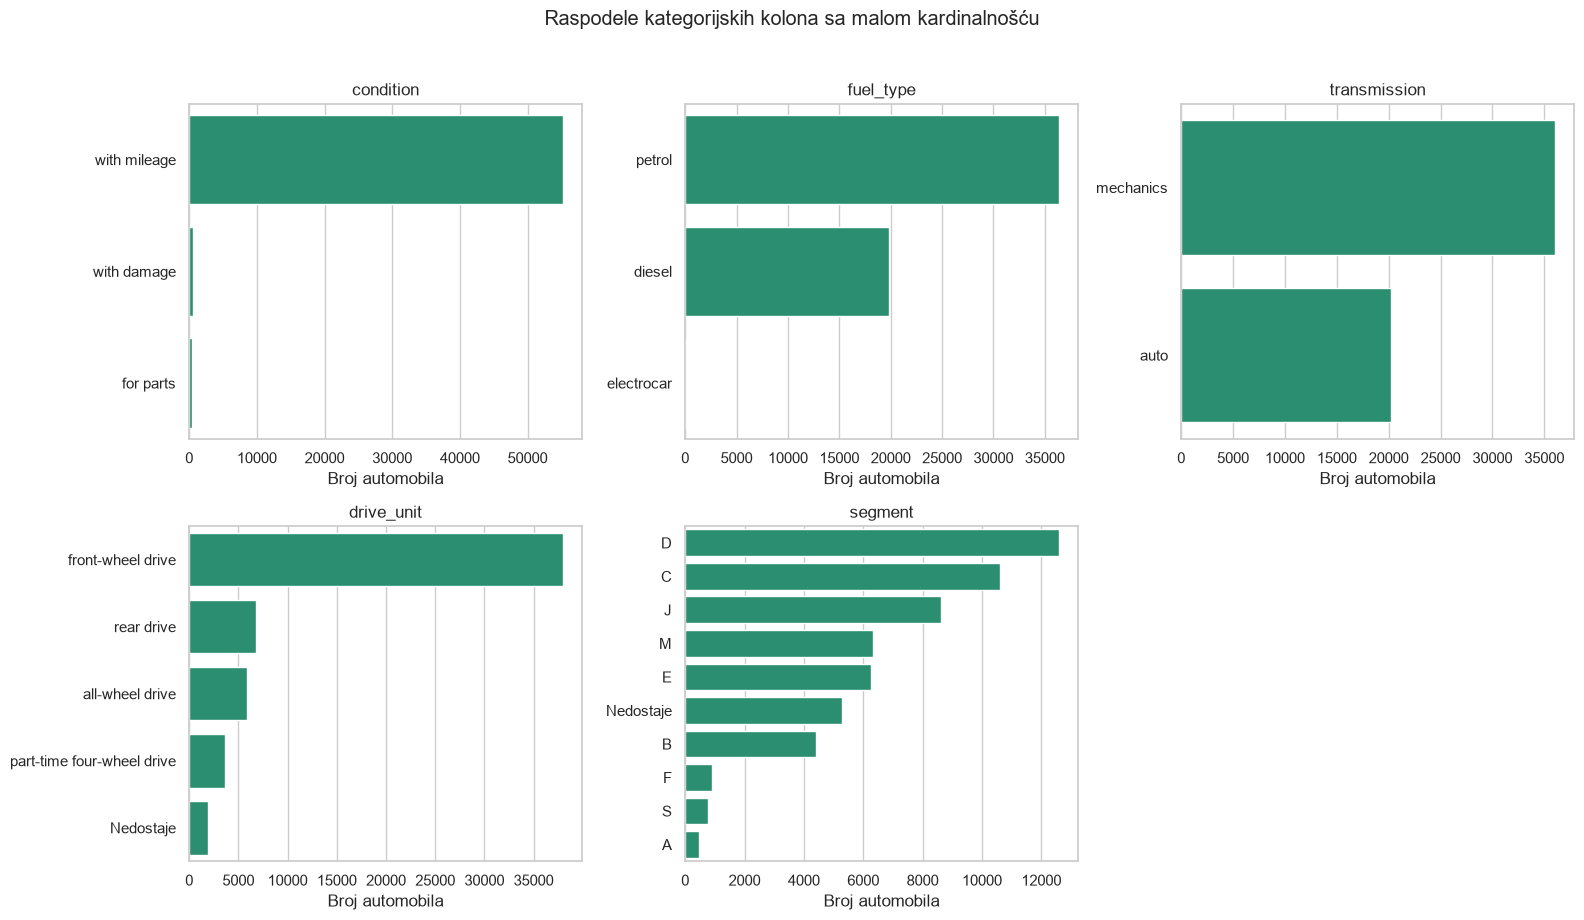

In [16]:
categorical_columns = cars.select_dtypes(exclude="number").columns.tolist()

categorical_summary = cars[categorical_columns].describe().T.rename(

    columns={"count": "broj_popunjenih", "unique": "broj_kategorija", "top": "najcesca", "freq": "frekvencija"}

)

categorical_summary["udeo_najcesce_%"] = (

    categorical_summary["frekvencija"] / categorical_summary["broj_popunjenih"] * 100

)

print("Kategorijske kolone:", categorical_columns)

display(categorical_summary.style.format({"udeo_najcesce_%": "{:.2f}%"}))



plot_columns = ["condition", "fuel_type", "transmission", "drive_unit", "segment"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for column, ax in zip(plot_columns, axes.flat):

    plot_data = cars[column].fillna("Nedostaje")

    order = plot_data.value_counts().index

    sns.countplot(y=plot_data, order=order, ax=ax, color="#1b9e77")

    ax.set_title(column)

    ax.set_xlabel("Broj automobila")

    ax.set_ylabel("")

axes.flat[-1].axis("off")

fig.suptitle("Raspodele kategorijskih kolona sa malom kardinalnošću", y=1.02)

plt.tight_layout()

plt.show()

## 7. Ekstremne vrednosti



Ekstremne vrednosti se identifikuju IQR pravilom: vrednost je kandidat za autlajer ako je manja od $Q_1 - 1.5 \cdot IQR$ ili veća od $Q_3 + 1.5 \cdot IQR$. Ova oznaka ne znači automatski da je red nevalidan; poslovno značenje i kvalitet podatka moraju se proveriti pre uklanjanja.

,minimum,donja_granica,gornja_granica,maksimum,broj_ekstremnih,udeo_ekstremnih_%
kolona,,,,,,
priceUSD,48.00,"-8,836.25","20,993.75","235,235.00",2551,4.54%
year,"1,910.00","1,980.00","2,028.00","2,019.00",258,0.46%
mileage(kilometers),0.00,"-122,500.00","569,500.00","9,999,999.00",689,1.23%
volume(cm3),500.00,550.00,"3,350.00","20,000.00",3618,6.43%


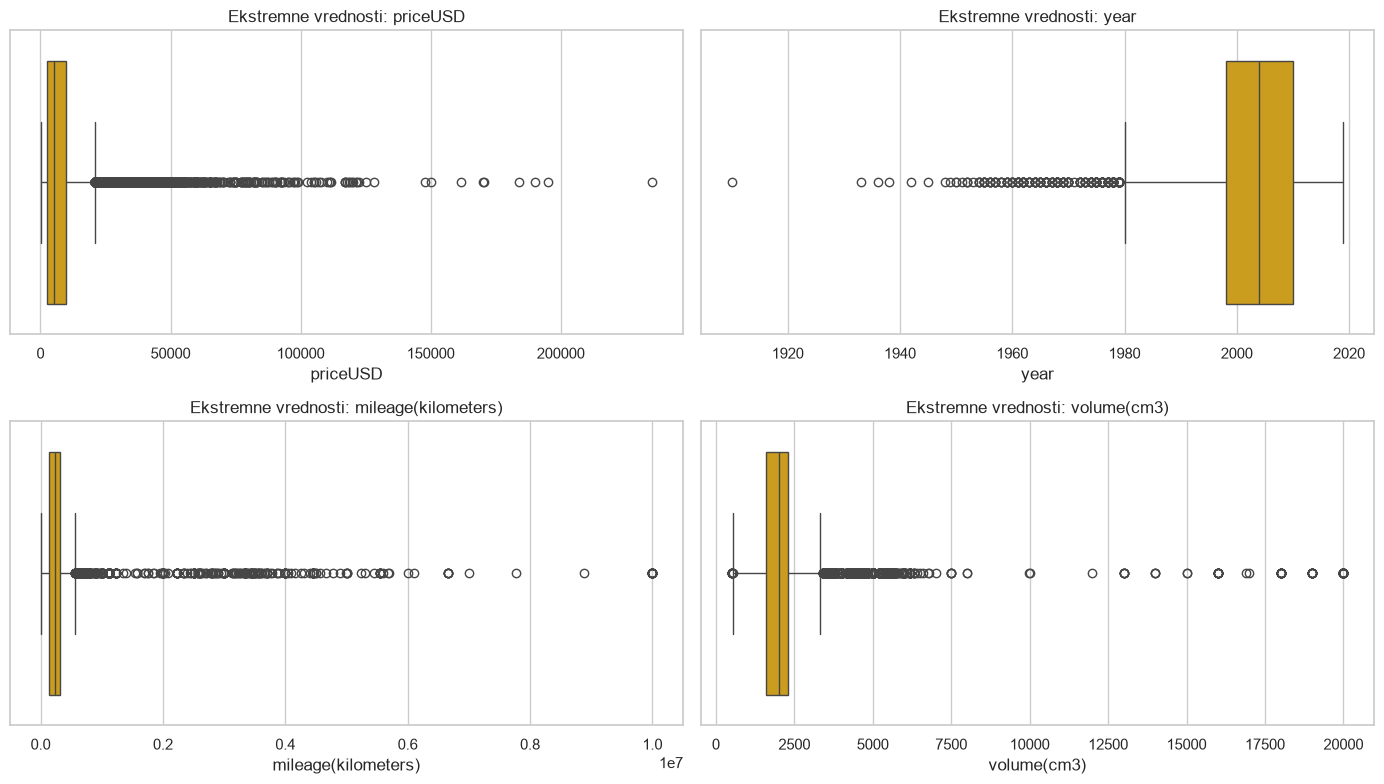

,make,model,priceUSD,year,mileage(kilometers)
20787,bentley,continental-gt,235235,2018,29000.0
16430,bentley,bentayga,195000,2016,72000.0
35457,bentley,mulsanne,190141,2014,36500.0
16428,bentley,bentayga,183848,2016,22000.0
16429,bentley,bentayga,170477,2016,74100.0
19557,porsche,cayenne,170000,2018,1020.0
34508,tesla,model-x,161563,2019,50.0
26254,mercedes-benz,g-klass,150000,2001,160000.0
33702,mercedes-benz,maybach,148000,2019,950.0
33327,bmw,m5,128136,2019,2925.0


In [17]:
outlier_rows = []

for column in numeric_columns:

    series = cars[column].dropna()

    q1, q3 = series.quantile([0.25, 0.75])

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr

    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (cars[column] < lower_bound) | (cars[column] > upper_bound)

    outlier_rows.append({

        "kolona": column,

        "minimum": series.min(),

        "donja_granica": lower_bound,

        "gornja_granica": upper_bound,

        "maksimum": series.max(),

        "broj_ekstremnih": int(outlier_mask.sum()),

        "udeo_ekstremnih_%": outlier_mask.mean() * 100,

    })



outlier_summary = pd.DataFrame(outlier_rows).set_index("kolona")

display(outlier_summary.style.format({

    "minimum": "{:,.2f}",

    "donja_granica": "{:,.2f}",

    "gornja_granica": "{:,.2f}",

    "maksimum": "{:,.2f}",

    "udeo_ekstremnih_%": "{:.2f}%",

}))



fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for column, ax in zip(numeric_columns, axes.flat):

    sns.boxplot(x=cars[column], ax=ax, color="#e6ab02")

    ax.set_title(f"Ekstremne vrednosti: {column}")

plt.tight_layout()

plt.show()



display(cars.nlargest(10, "priceUSD")[["make", "model", "priceUSD", "year", "mileage(kilometers)"]])

## Zaključak EDA analize



- Skup sadrži **56.244 reda i 12 kolona**, uz **87 potpuno dupliranih redova** koje treba proveriti u fazi čišćenja.

- Nedostajuće vrednosti postoje u kolonama `segment` (**9,41%**), `drive_unit` (**3,39%**) i `volume(cm3)` (**0,08%**). Ciljna promenljiva nema nedostajuće vrednosti.

- Medijana cene je **5.350 USD**, dok je prosek približno **7.415 USD**. Koeficijent asimetrije od **5,14** potvrđuje snažno desno asimetričnu raspodelu, pa treba razmotriti logaritamsku transformaciju cilja i koristiti metrike otporne na ekstremne vrednosti.

- Godina proizvodnje ima najjaču linearnu vezu sa cenom među postojećim numeričkim atributima (korelacija približno **0,61**). Kilometraža je negativno povezana sa cenom (približno **-0,17**).

- `make` ima 96, a `model` 1.034 kategorije, što zahteva pažljivo kodiranje retkih kategorija u pretprocesiranju. Kolona `condition` je izrazito neuravnotežena jer kategorija `with mileage` čini približno 98% popunjenih vrednosti.

- IQR pravilo označava potencijalne autlajere, ali oni se ne smeju automatski ukloniti. Visoke cene luksuznih vozila deluju moguće, dok vrednosti poput **9.999.999 km** i **20.000 cm³** zahtevaju proveru i definisanje poslovno opravdanih granica u `data_cleaning.py`.